In [1]:
from pathlib import Path
import os
import json
from datetime import datetime
import pandas as pd
import seaborn as sns

from gulp2p.preproc import utils
from gulp2p.preproc.tiff import Tiff
from gulp2p.config import BHV_DATA_RAW_DIR

config loaded


In [2]:
tiff_path = Path(r"Z:\2PImaging\Kerstin\MIMS\20231207\20231207_DR019xiGluSnFr_Fly1_00001.tif")

In [3]:
tiff = Tiff(tiff_path)
# tiff.length

In [4]:
bhv_paths = utils.get_bhv_paths(tiff, BHV_DATA_RAW_DIR)
for bhv_path in bhv_paths:
    overlap = utils.get_tiff_bhv_overlap(tiff, bhv_path)
    print(bhv_path, overlap)

Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2023-12-07_09-52-21.json [0.0, 340.89847350120544]


In [5]:
len(list(BHV_DATA_RAW_DIR.rglob('*')))

998

In [6]:
df_dicts = []
for bhv_path in BHV_DATA_RAW_DIR.rglob('*'):
    if bhv_path.suffix != ".json":
        continue
    if bhv_path.name == "SessionParameters.json":
        continue

    file_mb = bhv_path.stat().st_size / (2**20)
    length = utils.get_bhv_length(bhv_path)
    timestamp = utils.get_timestamp_from_string(bhv_path.name)
    data = {"path": bhv_path,
            "size": file_mb,
            "length": length,
            "date": datetime.fromtimestamp(timestamp)}
    df_dicts.append(data)

stat_df = pd.DataFrame(df_dicts)

In [7]:
stat_df['size_per_length'] = stat_df['size'] / stat_df['length']

(0.0, 750.0)

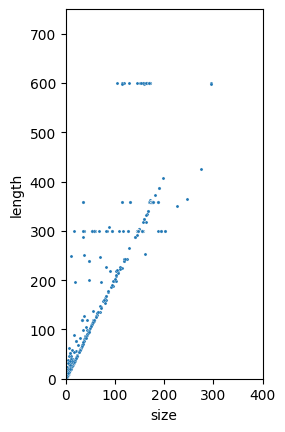

In [8]:
# ax = sns.scatterplot(data=stat_df, x="date", y="size_per_length")
ax = sns.scatterplot(data=stat_df, x="size", y="length",
                     s=5)
ax.set_aspect("equal")
# fig = ax.figure
# fig.set_size_inches((15,5))
ax.set_xlim([0, 400])
ax.set_ylim([0, 750])

In [9]:
fictrac_video_folder = Path(r"Z:\Live Fly Imaging data\fictrac")

In [10]:
# Check if a vid 

In [11]:
new_tiff_path = Path(r"Z:\2PImaging\Kerstin\MIMS\20240212\20240212_DR018xiGluSnFR_Fly01_00002.tif")
video_path = Path(r"Z:\Live Fly Imaging data\fictrac\fictrac-raw-20240212_141456.avi")
# ffmpeg_video_path = Path(r"Z:\Live Fly Imaging data\fictrac\fictrac-dbg-20240110_113229_copy.avi")
new_tiff = Tiff(new_tiff_path)

In [12]:
utils.get_vid_length(video_path)

2158.011363

In [13]:
print(new_tiff.metadata['date'])

2024-02-12 14:29:51.329901


In [14]:
new_tiff.length

314.14212

In [15]:
vid_paths = utils.get_vid_paths(new_tiff, fictrac_video_folder)
for vid_path in vid_paths:
    overlap = utils.get_tiff_vid_overlap(new_tiff, vid_path)
    print(vid_path, overlap)

Z:\Live Fly Imaging data\fictrac\fictrac-dbg-20240212_141456.avi [0.0, 314.14211988449097]
Z:\Live Fly Imaging data\fictrac\fictrac-raw-20240212_141456.avi [0.0, 314.14211988449097]
